# Assignment 1 – Canadian Health & Income Data Analysis with Visualization

**Objective:** This assignment demonstrates the application of data analysis concepts from weeks 1-2, including data type identification, data cleaning and structuring, visual aesthetic mapping, color scale selection, and cognitive design principles applied to Canadian health and income survey data.

**Dataset:** Canadian_Health_Survey_Sample.csv

---

## Required Libraries

In [22]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set display options for better readability
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)

# Set visualization style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")

print("Libraries imported successfully!")

Libraries imported successfully!


---
# Part A – Data Exploration (20 marks)

## A1) Loading the Dataset

In [23]:
# A1) Load the CSV file into a pandas DataFrame
# Update the path to match your file location
df = pd.read_csv('Canadian_Health_Survey_Sample.csv')

print(f"Dataset loaded successfully!")
print(f"Shape: {df.shape[0]} rows × {df.shape[1]} columns")

Dataset loaded successfully!
Shape: 850 rows × 9 columns


## A2) Initial Data Inspection

In [24]:
# A2) Show the first 5 rows of the dataset
df.head()

,Province,Gender,Age,Income,BMI,PhysicalActivity,Smoking,SelfRatedHealth,StressLevel
0,Ontario,female,59,80572.0,25.7,3.8,yes,Good,6.0
1,New Brunswick,Male,38,125739.0,24.2,3.4,No,Good,9.0
2,Nova Scotia,M,31,55997.0,35.7,NaN,No,Excellent,NaN
3,Saskatchewan,Male,30,75947.0,28.3,3.9,No,Excellent,10.0
4,Saskatchewan,female,79,113966.0,31.2,1.6,No,Fair,6.0


In [25]:
# Show data structure and types
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 850 entries, 0 to 849
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Province          850 non-null    str    
 1   Gender            850 non-null    str    
 2   Age               850 non-null    int64  
 3   Income            816 non-null    float64
 4   BMI               808 non-null    float64
 5   PhysicalActivity  825 non-null    float64
 6   Smoking           850 non-null    str    
 7   SelfRatedHealth   850 non-null    str    
 8   StressLevel       825 non-null    float64
dtypes: float64(4), int64(1), str(4)
memory usage: 59.9 KB


In [26]:
# Show summary statistics for all columns
df.describe(include='all')

,Province,Gender,Age,Income,BMI,PhysicalActivity,Smoking,SelfRatedHealth,StressLevel
count,850,850,850.000000,816.000000,808.000000,825.000000,850,850,825.000000
unique,10,6,NaN,NaN,NaN,NaN,6,5,NaN
top,Quebec,Male,NaN,NaN,NaN,NaN,No,Good,NaN
freq,100,230,NaN,NaN,NaN,NaN,552,258,NaN
mean,NaN,NaN,49.517647,77461.917892,27.488861,3.511394,NaN,NaN,5.294545
std,NaN,NaN,18.192604,22497.833440,5.064344,1.925825,NaN,NaN,2.121156
min,NaN,NaN,18.000000,5000.000000,13.500000,0.000000,NaN,NaN,1.000000
25%,NaN,NaN,33.000000,63438.000000,24.000000,2.100000,NaN,NaN,4.000000
50%,NaN,NaN,49.000000,78130.000000,27.300000,3.500000,NaN,NaN,5.000000
75%,NaN,NaN,66.000000,90529.500000,30.900000,4.700000,NaN,NaN,7.000000


---
# Part B – Data Cleaning & Preparation (30 marks)

## B1) Normalizing Categorical Data (Gender and Smoking)

In [27]:
# B1) Standardize categorical values

# Create a copy to preserve original data
df_clean = df.copy()

# Normalize Gender to {'Male', 'Female'}
gender_mapping = {
    'Male': 'Male', 'male': 'Male', 'M': 'Male', 'm': 'Male',
    'Female': 'Female', 'female': 'Female', 'F': 'Female', 'f': 'Female'
}
df_clean['Gender'] = df_clean['Gender'].map(gender_mapping)

# Normalize Smoking to {'Yes', 'No'}
smoking_mapping = {
    'Yes': 'Yes', 'yes': 'Yes', 'Y': 'Yes', 'y': 'Yes',
    'No': 'No', 'no': 'No', 'N': 'No', 'n': 'No'
}
df_clean['Smoking'] = df_clean['Smoking'].map(smoking_mapping)

print("Gender unique values:", df_clean['Gender'].unique())
print("Smoking unique values:", df_clean['Smoking'].unique())

Gender unique values: <StringArray>
['Female', 'Male']
Length: 2, dtype: str
Smoking unique values: <StringArray>
['Yes', 'No']
Length: 2, dtype: str


## B2) Handling Missing Data

In [28]:
# B2) Handle missing values for BMI, Income, StressLevel, PhysicalActivity

missing_cols = ['BMI', 'Income', 'StressLevel', 'PhysicalActivity']

print("Missing values:")
print(df_clean[missing_cols].isnull().sum())

print("\nJUSTIFICATION: Using MEDIAN IMPUTATION")
print("- Median is resistant to outliers (important for Income and BMI)")
print("- Preserves discrete nature of ordinal variables (StressLevel, PhysicalActivity)")
print("- Missing values < 5% - deletion would reduce statistical power")
print("- Missing pattern appears random (MAR)")

# Apply median imputation
for col in missing_cols:
    median_val = df_clean[col].median()
    df_clean[col] = df_clean[col].fillna(median_val)
    print(f"\n{col}: Filled with median = {median_val:.2f}")

print("\nMissing values after imputation:")
print(df_clean[missing_cols].isnull().sum())

Missing values:
BMI                 42
Income              34
StressLevel         25
PhysicalActivity    25
dtype: int64

JUSTIFICATION: Using MEDIAN IMPUTATION
- Median is resistant to outliers (important for Income and BMI)
- Preserves discrete nature of ordinal variables (StressLevel, PhysicalActivity)
- Missing values < 5% - deletion would reduce statistical power
- Missing pattern appears random (MAR)

BMI: Filled with median = 27.30

Income: Filled with median = 78130.00

StressLevel: Filled with median = 5.00

PhysicalActivity: Filled with median = 3.50

Missing values after imputation:
BMI                 0
Income              0
StressLevel         0
PhysicalActivity    0
dtype: int64


## B3) Converting Data Types

In [29]:
# B3) Enforce data types: Age (int), Income (float), BMI (float), StressLevel (int)

df_clean['Age'] = df_clean['Age'].astype(int)
df_clean['Income'] = df_clean['Income'].astype(float)
df_clean['BMI'] = df_clean['BMI'].astype(float)
df_clean['StressLevel'] = df_clean['StressLevel'].astype(int)

print("Data types after conversion:")
print(df_clean[['Age', 'Income', 'BMI', 'StressLevel']].dtypes)

Data types after conversion:
Age              int64
Income         float64
BMI            float64
StressLevel      int64
dtype: object


## B4) Creating New Derived Variables (BMI_Category and IncomeBracket)

BMI_Category Distribution:
BMI_Category
Underweight     29
Normal         227
Overweight     343
Obese          251
Name: count, dtype: int64

IncomeBracket Distribution:
IncomeBracket
<50k        75
50-80k     411
80-110k    323
>110k       41
Name: count, dtype: int64


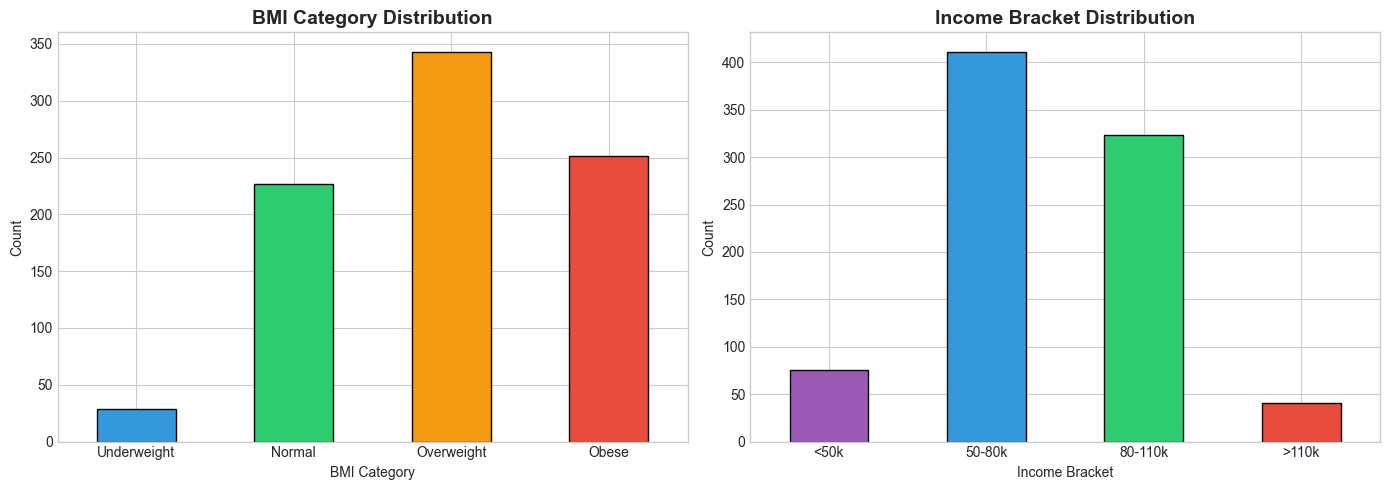

In [30]:
# B4) Create derived columns: BMI_Category and IncomeBracket

# Create BMI_Category: Underweight (<18.5), Normal (18.5-25), Overweight (25-30), Obese (≥30)
bmi_bins = [0, 18.5, 25, 30, float('inf')]
bmi_labels = ['Underweight', 'Normal', 'Overweight', 'Obese']
df_clean['BMI_Category'] = pd.cut(df_clean['BMI'], bins=bmi_bins, labels=bmi_labels, right=False)

# Create IncomeBracket: <50k, 50-80k, 80-110k, >110k
income_bins = [0, 50000, 80000, 110000, float('inf')]
income_labels = ['<50k', '50-80k', '80-110k', '>110k']
df_clean['IncomeBracket'] = pd.cut(df_clean['Income'], bins=income_bins, labels=income_labels, right=False)

print("BMI_Category Distribution:")
print(df_clean['BMI_Category'].value_counts().sort_index())

print("\nIncomeBracket Distribution:")
print(df_clean['IncomeBracket'].value_counts().sort_index())

# Visualize the new categories
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df_clean['BMI_Category'].value_counts().sort_index().plot(kind='bar', ax=axes[0], 
    color=['#3498db', '#2ecc71', '#f39c12', '#e74c3c'], edgecolor='black')
axes[0].set_title('BMI Category Distribution', fontsize=14, fontweight='bold')
axes[0].set_xlabel('BMI Category')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=0)

df_clean['IncomeBracket'].value_counts().sort_index().plot(kind='bar', ax=axes[1],
    color=['#9b59b6', '#3498db', '#2ecc71', '#e74c3c'], edgecolor='black')
axes[1].set_title('Income Bracket Distribution', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Income Bracket')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

---
# Part C – Data Visualization (30 marks)

## C1) Bar Chart: Provincial Health Score Comparison

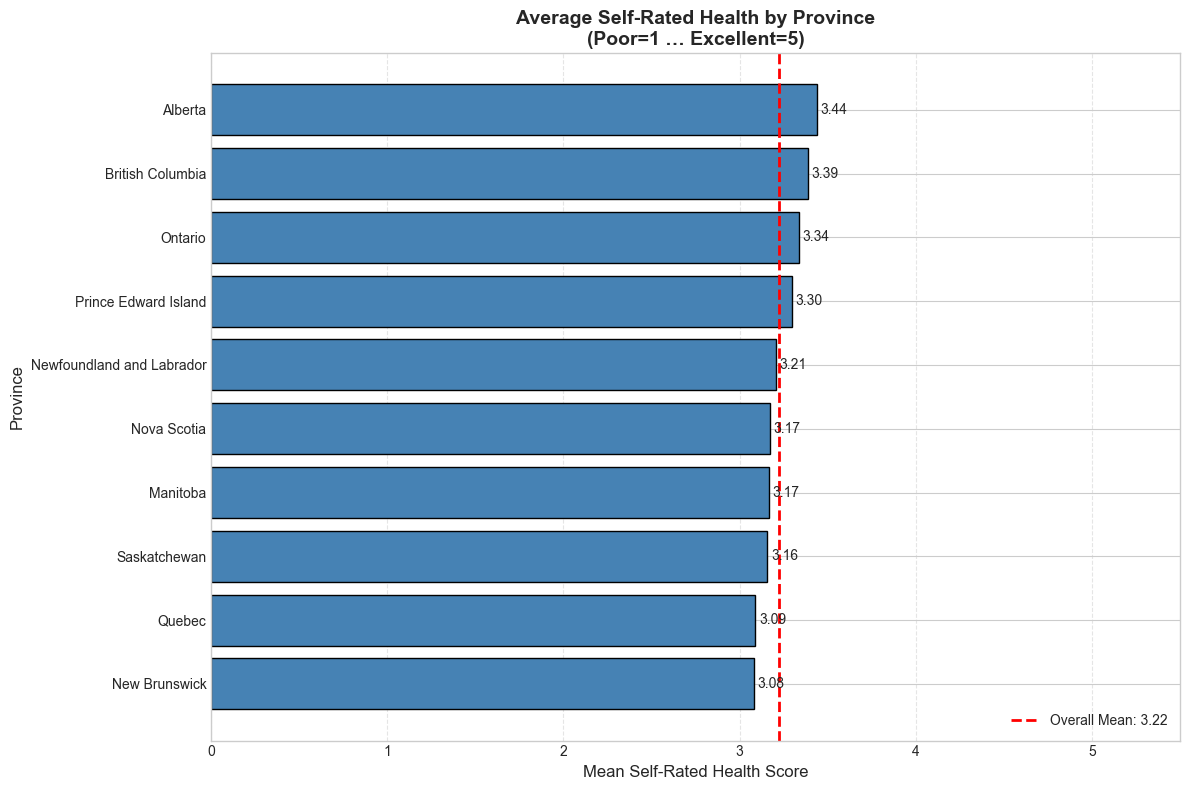

In [31]:
# C1) Bar chart: Average Life/Health proxy by Province

# Map SelfRatedHealth to numeric: Poor=1, Fair=2, Good=3, Very Good=4, Excellent=5
health_mapping = {
    'Poor': 1,
    'Fair': 2,
    'Good': 3,
    'Very Good': 4,
    'Excellent': 5
}
df_clean['SelfRatedHealth_num'] = df_clean['SelfRatedHealth'].map(health_mapping)

# Calculate mean health by province
health_by_province = df_clean.groupby('Province')['SelfRatedHealth_num'].mean().sort_values()

# Create bar chart
fig, ax = plt.subplots(figsize=(12, 8))

bars = ax.barh(health_by_province.index, health_by_province.values, color='steelblue', edgecolor='black')

# Add value labels
for bar, value in zip(bars, health_by_province.values):
    ax.text(value + 0.02, bar.get_y() + bar.get_height()/2, f'{value:.2f}',
            va='center', fontsize=10)

# Add overall mean reference line
overall_mean = df_clean['SelfRatedHealth_num'].mean()
ax.axvline(x=overall_mean, color='red', linestyle='--', linewidth=2,
           label=f'Overall Mean: {overall_mean:.2f}')

ax.set_xlabel('Mean Self-Rated Health Score', fontsize=12)
ax.set_ylabel('Province', fontsize=12)
ax.set_title('Average Self-Rated Health by Province\n(Poor=1 … Excellent=5)', fontsize=14, fontweight='bold')
ax.set_xlim(0, 5.5)
ax.xaxis.grid(True, linestyle='--', alpha=0.5)
ax.legend(loc='lower right')

plt.tight_layout()
plt.show()

## C2) Scatter Plot: Exploring Income vs BMI with Additional Encodings

C2: INCOME vs BMI SCATTER PLOT


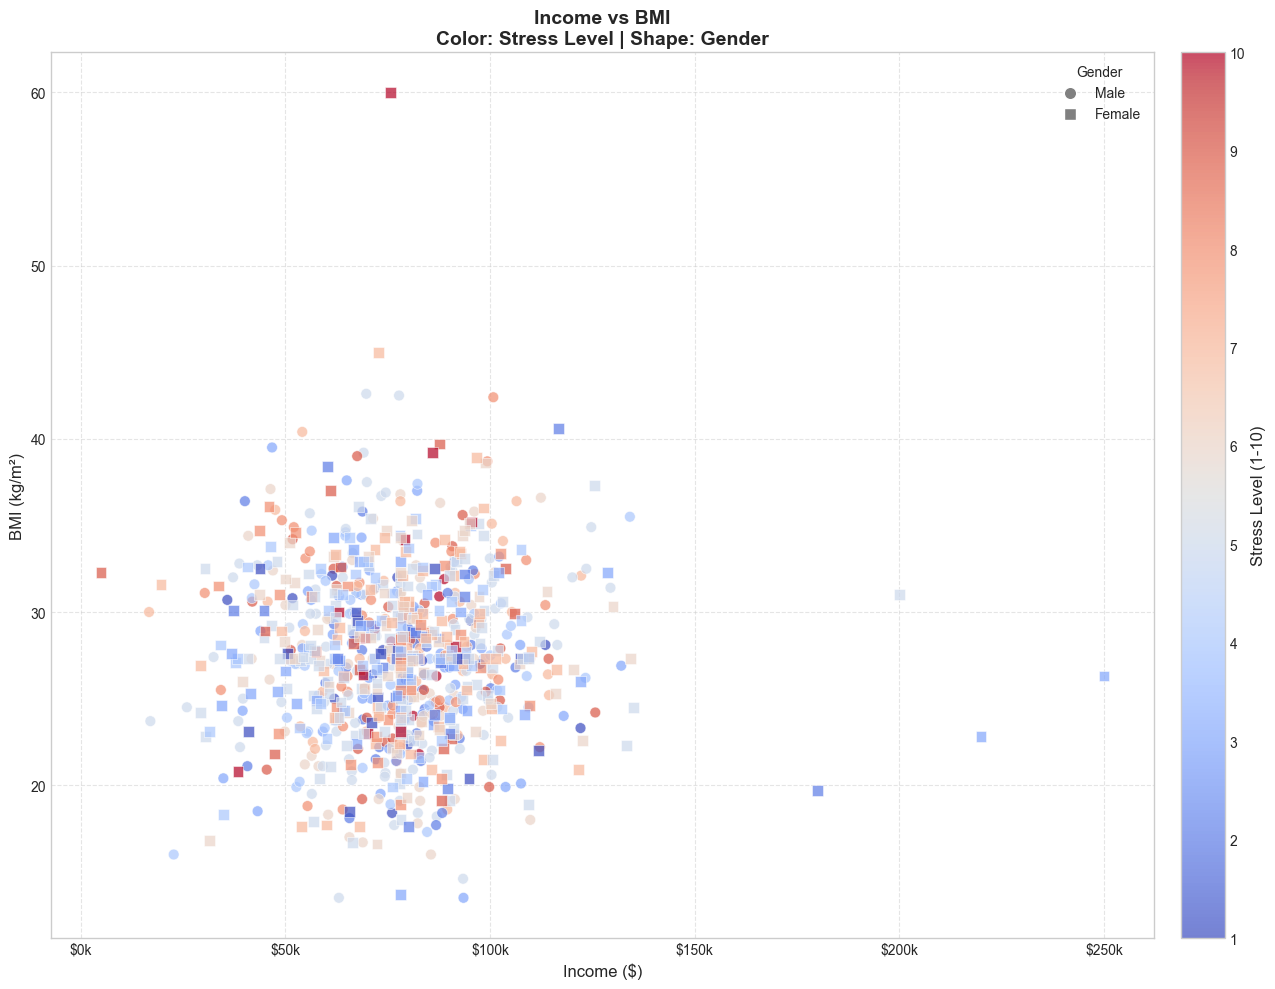


Correlation between Income and BMI: 0.0022


In [ ]:
# C2) Scatter plot: Income vs BMI with color=StressLevel, shape=Gender

fig, ax = plt.subplots(figsize=(14, 10))

# Define markers for gender
markers = {'Male': 'o', 'Female': 's'}

# Create scatter plot for each gender
for gender in ['Male', 'Female']:
    subset = df_clean[df_clean['Gender'] == gender]
    scatter = ax.scatter(
        subset['Income'], 
        subset['BMI'],
        c=subset['StressLevel'],
        cmap='coolwarm',
        marker=markers[gender],
        s=60,
        alpha=0.7,
        edgecolors='white',
        linewidth=0.5,
        label=f'{gender}',
        vmin=df_clean['StressLevel'].min(),
        vmax=df_clean['StressLevel'].max()
    )

# Add colorbar for StressLevel
cbar = plt.colorbar(scatter, ax=ax, pad=0.02)
cbar.set_label('Stress Level (1-10)', fontsize=12)
cbar.ax.tick_params(labelsize=10)

# Add legend for Gender
legend_elements = [
    plt.scatter([], [], marker='o', c='gray', s=80, label='Male', edgecolors='white'),
    plt.scatter([], [], marker='s', c='gray', s=80, label='Female', edgecolors='white')
]
ax.legend(handles=legend_elements, title='Gender', loc='upper right', fontsize=10)

# Customize axes
ax.set_xlabel('Income ($)', fontsize=12)
ax.set_ylabel('BMI (kg/m²)', fontsize=12)
ax.set_title('Income vs BMI\nColor: Stress Level | Shape: Gender', fontsize=14, fontweight='bold')
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x/1000:.0f}k'))
ax.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

## C3) Diverging Visualization: Provincial Health Deviations

Overall Mean Health Score: 3.2224

ΔLifeProxy (Province Mean - Overall Mean):
Province
New Brunswick               -0.1399
Quebec                      -0.1324
Saskatchewan                -0.0645
Manitoba                    -0.0537
Nova Scotia                 -0.0516
Newfoundland and Labrador   -0.0150
Prince Edward Island         0.0731
Ontario                      0.1150
British Columbia             0.1665
Alberta                      0.2188
Name: SelfRatedHealth_num, dtype: float64


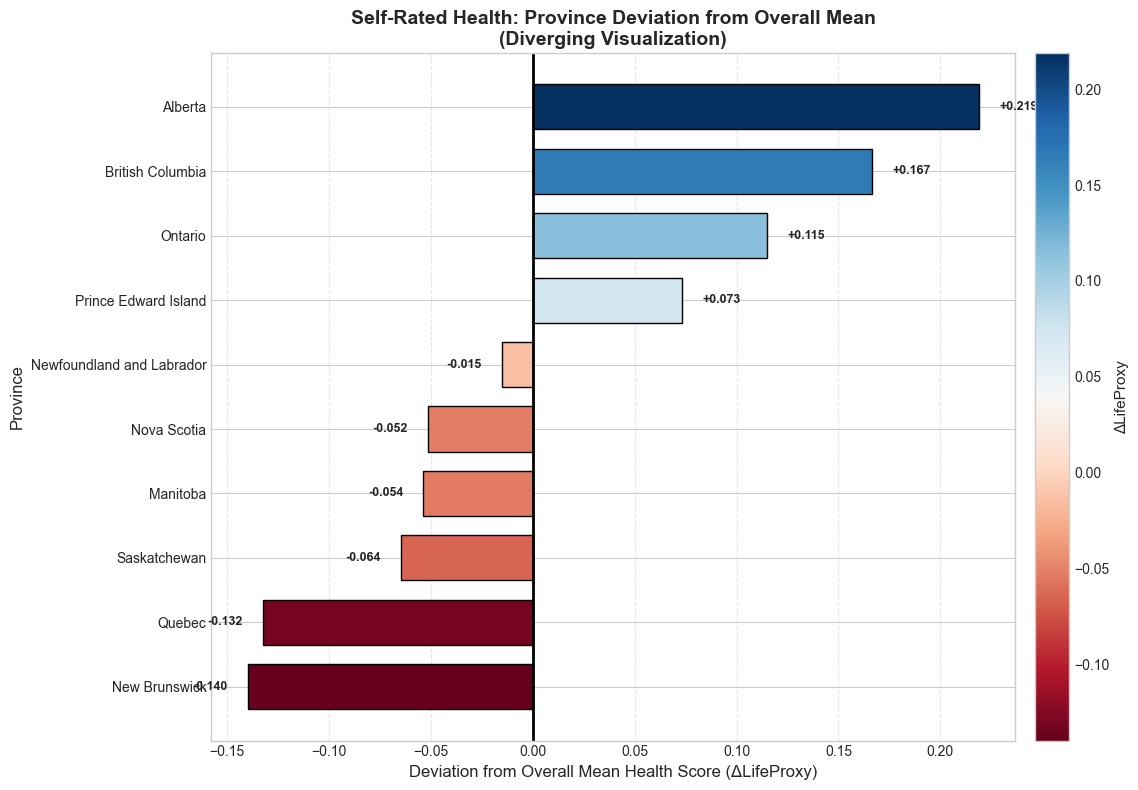

In [32]:
# C3) Diverging visualization: ΔLifeProxy = Province mean - overall mean

# Calculate overall mean
overall_mean = df_clean['SelfRatedHealth_num'].mean()

# Calculate province means and deviation from overall mean
province_health = df_clean.groupby('Province')['SelfRatedHealth_num'].mean()
delta_health = (province_health - overall_mean).sort_values()

print(f"Overall Mean Health Score: {overall_mean:.4f}")
print("\nΔLifeProxy (Province Mean - Overall Mean):")
print(delta_health.round(4))

# Create diverging bar chart
fig, ax = plt.subplots(figsize=(12, 8))

# Use continuous diverging colormap (RdBu)
norm = plt.Normalize(vmin=delta_health.min(), vmax=delta_health.max())
cmap = plt.cm.RdBu
colors = [cmap(norm(val)) for val in delta_health.values]

bars = ax.barh(delta_health.index, delta_health.values, color=colors, edgecolor='black', height=0.7)

# Add value labels
for bar, value in zip(bars, delta_health.values):
    x_pos = value + 0.01 if value >= 0 else value - 0.01
    ha = 'left' if value >= 0 else 'right'
    ax.text(x_pos, bar.get_y() + bar.get_height()/2, f'{value:+.3f}', 
            va='center', ha=ha, fontsize=9, fontweight='bold')

# Add vertical line at zero (overall mean)
ax.axvline(x=0, color='black', linewidth=2, linestyle='-')

# Customize chart
ax.set_xlabel('Deviation from Overall Mean Health Score (ΔLifeProxy)', fontsize=12)
ax.set_ylabel('Province', fontsize=12)
ax.set_title('Self-Rated Health: Province Deviation from Overall Mean\n(Diverging Visualization)', 
             fontsize=14, fontweight='bold')

# Add colorbar
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax, pad=0.02)
cbar.set_label('ΔLifeProxy', fontsize=11)

ax.xaxis.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

In [33]:
# Export cleaned data to CSV
df_clean.to_csv('Canadian_Health_Survey_Cleaned.csv', index=False)
print("✅ Cleaned data exported to: Canadian_Health_Survey_Cleaned.csv")
print(f"   Shape: {df_clean.shape[0]} rows × {df_clean.shape[1]} columns")

✅ Cleaned data exported to: Canadian_Health_Survey_Cleaned.csv
   Shape: 850 rows × 12 columns
